# Can polls call Senate winners? 

Third notebook on the [Open-Source-Election](https://github.com/903124/Open-Source-Election) data. Take every Senate race's final polling, turn it into a win rate — a probability the race's candidate wins — under a polling-error model where misses are correlated across states, then score the 2014 map against what happened.

Polling misses don't strike states at random. A cycle that understates one party in Colorado tends to understate it in Iowa and Kansas too. Treating state errors as independent double-counts certainty and makes the seat distribution tighter than election night ever feels. The model:

- **poll margin → predicted margin**: recency-weighted final-3-weeks polling average (two-party), plus an incumbency bump fitted on the training years. A presidential + House + statewide-office lean backstops races the polls skipped (the lean pipeline's sources minus same-cycle Senate — that one would leak the answer).
- **error = national + state**: each simulated night draws one shared national shock N(μ_nat, σ_nat²) plus an independent N(0, σ_state²) per race, both estimated from 2008/2010/2012.
- **win rate** = P(margin > 0) over 20,000 simulations.


| Data | Path |
|---|---|
| results (targets) | `data/senate/senate_general_results_{2008,2010,2012,2014}.csv` |
| polls (predictors) | `data/senate/senate_general_polling_{2008,2010,2012,2014}.csv` |
| backstop lean | `data/presidential/presidential_results_{2008,2012}.csv` + `data/house/house_results_{2008,2010,2012,2014}.csv` + `data/district_lean/district_lean{,_midterm}_{2008..2014}.csv` (statewide component) |

In [1]:
from pathlib import Path
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO = Path("../Open-Source-Election")
if not (REPO / "data").exists():          # notebook lives inside the repo
    REPO = Path("..")

pd.options.display.float_format = "{:.1f}".format
plt.rcParams.update({
    "figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 11,
})
PARTY_COLOR = {"d": "#2a6fdb", "r": "#d94040", "o": "#7a5195"}
YEAR_COLOR = {2008: "#9ecae1", 2010: "#4292c6", 2012: "#08519c", 2014: "#9a9a9a"}

TRAIN_YEARS = [2008, 2010, 2012]
TEST_YEAR = 2014
YEARS = TRAIN_YEARS + [TEST_YEAR]
ELECTION_DAY = {2008: "2008-11-04", 2010: "2010-11-02",
                2012: "2012-11-06", 2014: "2014-11-04"}
# two seats were decided by a later runoff — that runoff is the race
DATE_OVERRIDE = {(2008, "Georgia"): "2008-12-02",
                 (2014, "Louisiana"): "2014-12-06"}
BOX_OVERRIDE = {(2008, "Georgia"): "Runoff results"}
# the MS-2008 special was legally nonpartisan and wiki drops the party
# labels; restore them so Wicker (R) vs Musgrove (D) stays in training
PARTY_FIX = {(2008, "Mississippi (special)"): {"roger wicker": "r",
                                               "ronnie musgrove": "d"}}

WINDOW_DAYS, HALF_LIFE_DAYS, DEFAULT_SAMPLE = 21, 7.0, 600
SIMS, SEED = 20_000, 2014

def party_class(p):
    # wiki ships long forms: "Republican Party of Minnesota",
    # "Minnesota Democratic–Farmer–Labor Party", "Democratic Party (Alabama)"
    p = str(p or "").strip().lower()
    return "d" if re.search(r"democratic|dfl", p) else "r" if "republican" in p else "o"

def num(s):  # "2,100 (LV)" -> 2100.0
    digits = re.sub(r"[^\d]", "", str(s or ""))
    return float(digits) if digits else np.nan

warnings.simplefilter("ignore")
print("pandas", pd.__version__)

pandas 2.2.3


## 1 · The races

Each results CSV is candidate-per-election-box. A box becomes a race when it passes four filters: no "Undecided" line (that's an embedded poll table), a Republican present (kills primary-era convention tables), a named candidate above the walkover screen, and — for the multi-certification states — the final box wins. The left candidate is the top Democrat, or the top independent when no Democrat ran. Margin everywhere below is 100 · (left − right) / (left + right): two-party points, positive = D side ahead.

In [2]:
def build_races(year):
    res = pd.read_csv(REPO / f"data/senate/senate_general_results_{year}.csv")
    rows, dropped = [], []
    for (state, election), box in res.groupby(["State", "Election"], sort=False):
        label = f"{year} {state}"
        if BOX_OVERRIDE.get((year, state), election) != election:
            dropped.append((label, "not the race box (runoff override)"))
            continue
        cand = box[box["Row_Type"].isin(["Winning", "Candidate"])].copy()
        if (cand.empty or (cand["candidate"].astype(str)
                           .str.strip().str.lower() == "undecided").any()):
            dropped.append((label, "embedded poll table"))
            continue
        cand["key"] = (cand["candidate"].astype(str)
                       .str.replace(r"\s*\(write-in\)\s*$", "", regex=True)
                       .str.strip().str.lower())
        cand["pc"] = cand["party"].map(party_class)
        for fix_cand, fix_pc in PARTY_FIX.get((year, state), {}).items():
            cand.loc[cand.key == fix_cand, "pc"] = fix_pc
        if "r" not in set(cand["pc"]):
            dropped.append((label, "no Republican (convention table?)"))
            continue
        cand["votes_n"] = cand["votes"].map(num)
        # fusion ballots: one person, several party lines -> sum the votes
        agg = (cand.groupby("key", as_index=False)
               .agg(votes=("votes_n", "sum"), pc=("pc", "first"),
                    inc=("Incumbent", "max"), name=("candidate", "first")))
        d_row = agg[agg.pc == "d"].nlargest(1, "votes")
        r_row = agg[agg.pc == "r"].nlargest(1, "votes")
        left = d_row if len(d_row) else agg[agg.pc == "o"].nlargest(1, "votes")
        if not len(left) or not len(r_row):
            dropped.append((label, "no left candidate"))
            continue
        L, R = left.iloc[0], r_row.iloc[0]
        two, loser = L.votes + R.votes, min(L.votes, R.votes)
        if loser / two < 0.05:
            dropped.append((label, "walkover (<5% of two-party vote)"))
            continue
        rows.append({
            "year": year, "state": state,
            "election_day": pd.Timestamp(DATE_OVERRIDE.get((year, state), ELECTION_DAY[year])),
            "left_name": str(L["name"]).title().strip(),
            "left_party": L.pc, "left_inc": bool(L.inc),
            "right_name": str(R["name"]).title().strip(), "right_inc": bool(R.inc),
            "margin": 100 * (L.votes - R.votes) / two,
        })
    df = pd.DataFrame(rows)
    if len(df):
        df = df.drop_duplicates(["year", "state"], keep="last")  # final certified box
    return df, dropped

frames, drop_log = [], {}
for y in YEARS:
    df, drops = build_races(y)
    frames.append(df)
    drop_log[y] = drops
races = pd.concat(frames, ignore_index=True)

for y in YEARS:
    print(f"{y}: {len(drop_log[y])} boxes dropped -> "
          f"{(races.year == y).sum()} races kept")
print()
for y in YEARS:
    for label, why in drop_log[y]:
        print(f"  {label:28s} {why}")

print("\nleft candidates that are not Democrats:")
print(races.loc[races.left_party != "d",
                ["year", "state", "left_name", "left_party"]].to_string(index=False))

2008: 2 boxes dropped -> 34 races kept
2010: 3 boxes dropped -> 36 races kept
2012: 9 boxes dropped -> 33 races kept
2014: 2 boxes dropped -> 35 races kept

  2008 Arkansas                no Republican (convention table?)
  2008 Georgia                 not the race box (runoff override)
  2010 Connecticut             no left candidate
  2010 South Dakota            no left candidate
  2010 Utah                    no Republican (convention table?)
  2012 California              embedded poll table
  2012 California              embedded poll table
  2012 Massachusetts           no Republican (convention table?)
  2012 Texas                   no left candidate
  2012 Texas                   no Republican (convention table?)
  2012 Texas                   no Republican (convention table?)
  2012 Utah                    no left candidate
  2012 Utah                    no left candidate
  2012 Utah                    no Republican (convention table?)
  2014 Alabama                 no left c

In [3]:
def load_polls(year):
    p = pd.read_csv(REPO / f"data/senate/senate_general_polling_{year}.csv")
    p["pct"] = p["Pct"].astype(str).str.rstrip("%").astype(float)
    p["n"] = p["Sample"].map(num).fillna(DEFAULT_SAMPLE)
    p["end"] = pd.to_datetime(p["Date_End"], errors="coerce")
    return p.dropna(subset=["end"])

def surname(name):
    # strip party suffixes: "Al Franken (DFL)", "Heidi Heitkamp (D-NPL)"
    return re.sub(r"\s*\(.*\)$", "", str(name).strip()).upper().split()[-1]

def poll_margin(race, polls):
    ps = polls[polls["State"] == race.state].copy()
    if ps.empty:
        return np.nan, 0, 0
    sl, sr = surname(race.left_name), surname(race.right_name)
    if sl == sr:
        return np.nan, 0, 0
    ps["side"] = ps["Candidate"].map(surname).map({sl: "L", sr: "R"})
    ps = ps[ps["side"].notna() & ps["pct"].notna()]
    ps["Date_Start"] = ps["Date_Start"].fillna("")
    inst = ps.pivot_table(index=["Poll_Source", "Date_Start", "end", "n"],
                          columns="side", values="pct", aggfunc="mean")
    if not {"L", "R"} <= set(inst.columns):
        return np.nan, 0, 0
    inst = inst.dropna(subset=["L", "R"])
    elec = race.election_day
    end = inst.index.get_level_values("end")
    inst = inst[(end >= elec - pd.Timedelta(days=WINDOW_DAYS)) & (end <= elec)]
    if not len(inst):
        return np.nan, 0, 0
    end = inst.index.get_level_values("end")
    days = np.asarray((elec - end).days, dtype=float)
    ns = np.asarray(inst.index.get_level_values("n"), dtype=float)
    w = 0.5 ** (days / HALF_LIFE_DAYS) * np.sqrt(ns)
    L, R = inst["L"].values, inst["R"].values
    m = 100 * (L - R) / (L + R)
    return float((m * w).sum() / w.sum()), len(inst), float(ns.sum())

poll_tables = {y: load_polls(y) for y in YEARS}
pm = races.apply(lambda r: poll_margin(r, poll_tables[r.year]), axis=1)
races[["poll_margin", "n_polls", "n_respondents"]] = pd.DataFrame(pm.tolist(),
                                                                  index=races.index)

cov = races.groupby("year").agg(
    races=("state", "count"), with_polls=("poll_margin", lambda s: s.notna().sum()),
    mean_polls=("n_polls", "mean"))
print("final-window coverage by year:")
print(cov.to_string())

print("\nraces the polls skipped:")
nopoll = races[races.poll_margin.isna()]
for y, grp in nopoll.groupby("year"):
    print(f"  {y}: {', '.join(grp.state)}")

final-window coverage by year:
      races  with_polls  mean_polls
year                               
2008     34          24         2.6
2010     36          33         5.4
2012     33          27         5.0
2014     35          34         5.8

races the polls skipped:
  2008: Alabama, Delaware, Idaho, Illinois, Massachusetts, Michigan, Mississippi, Nebraska, Rhode Island, South Dakota
  2010: Alabama, Massachusetts (special), Oklahoma
  2012: Delaware, Mississippi, Tennessee, Vermont, West Virginia, Wyoming
  2014: South Dakota


biggest competitive 2014 misses: Arkansas (-6 -> -18), Kansas (+0 -> -11), Virginia (+9 -> +1)


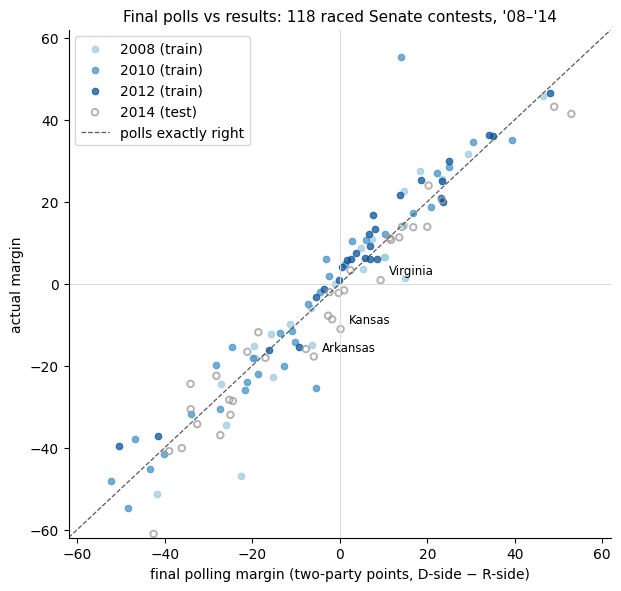

In [4]:
fig, ax = plt.subplots(figsize=(7.0, 6.6))
for y in YEARS:
    sub = races[(races.year == y) & races.poll_margin.notna()]
    is_test = y == TEST_YEAR
    ax.scatter(sub.poll_margin, sub.margin, s=22, alpha=0.75,
               facecolor="none" if is_test else YEAR_COLOR[y],
               edgecolor=YEAR_COLOR[y], linewidth=1.4 if is_test else 0.8,
               label=f"{y} ({'test' if is_test else 'train'})")
lim = 62
ax.plot([-lim, lim], [-lim, lim], color="0.35", lw=0.9, ls="--", label="polls exactly right")
ax.plot([-lim, lim], [0, 0], color="0.85", lw=0.7)
ax.plot([0, 0], [-lim, lim], color="0.85", lw=0.7)
ax.set(xlabel="final polling margin (two-party points, D-side − R-side)",
       ylabel="actual margin", xlim=(-lim, lim), ylim=(-lim, lim),
       title="Final polls vs results: 118 raced Senate contests, '08–'14")
ax.legend(loc="upper left")

# label the competitive 2014 misses
test_err = (races.year == TEST_YEAR) & races.poll_margin.notna() & (races.margin.abs() < 20)
big3 = races[test_err].assign(e=lambda d: (d.margin - d.poll_margin).abs()).nlargest(3, "e")
for _, r in big3.iterrows():
    ax.annotate(r.state, (r.poll_margin, r.margin), fontsize=8.5,
                xytext=(6, 4), textcoords="offset points")
print("biggest competitive 2014 misses:",
      ", ".join(f"{r.state} ({r['poll_margin']:+.0f} -> {r.margin:+.0f})"
                for _, r in big3.iterrows()))

It shows a good agreement from polling to final result

1495 contested House district-years; national D two-party: 2008 53.3, 2010 48.0, 2012 51.1, 2014 46.7
statewide component state-years per cycle: 2008 19, 2010 42, 2012 24, 2014 43
races with no lean: []
lean -> actual margin (train): margin = 1.21 * lean -1.5,  r2 = 0.44


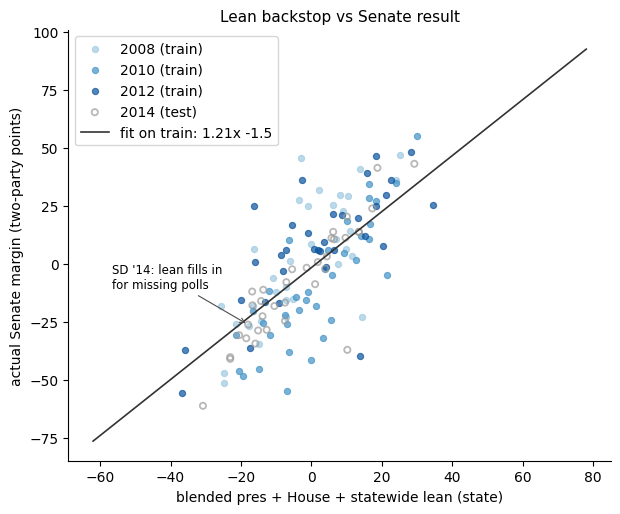

In [5]:
# Backstop lean, state level: presidential county sums + the state's House
# races + the lean pipeline's statewide component (governor / other
# executive offices / state-legislature chamber totals, already shifted by
# its own national baseline in the shipped lean CSVs), blended at the
# pipeline's weights (pres .40 / house .20 / statewide .20, renormalised —
# pres .67 / house .33 where the statewide component is missing).
# Same-cycle Senate results stay out on purpose — they would hand the
# answer to the no-poll races.
PRES = pd.concat([pd.read_csv(REPO / f"data/presidential/presidential_results_{y}.csv")
                  for y in (2008, 2012)])
PRES["pc"] = PRES["party"].map(party_class)
tot = PRES.groupby(["year", "state_code", "pc"])["votes"].sum().unstack()
pres_lean = (100 * (tot["d"] - tot["r"]) / (tot["d"] + tot["r"])).unstack("year")

HOUSE = pd.concat([pd.read_csv(REPO / f"data/house/house_results_{y}.csv",
                               dtype={"district": str}) for y in YEARS])
# house CSV carries every state -> the state-name map (presidential has no
# county rows for Alaska, so it can't be the source)
STATE_CODE = dict(HOUSE[["state", "state_code"]].drop_duplicates().values)
HOUSE["_v"] = pd.to_numeric(HOUSE["votes"], errors="coerce")
HOUSE["_pct"] = pd.to_numeric(HOUSE["percentage"], errors="coerce")
HOUSE["_tv"] = pd.to_numeric(HOUSE["total_votes"], errors="coerce")
HOUSE["_tv"] = HOUSE.groupby(["year", "state_code", "district"])["_tv"].transform("max")
est = HOUSE["_pct"] / 100 * HOUSE["_tv"]
# some boxes omit (or corrupt) the winner's raw votes; percentage x turnout is stable
use_est = (est.notna()
           & (HOUSE["_v"].isna() | ((HOUSE["_v"] - est).abs() > 0.02 * HOUSE["_tv"])))
HOUSE.loc[use_est, "_v"] = est[use_est]
HOUSE["pc"] = HOUSE["party"].map(party_class)
hd = (HOUSE[~HOUSE["state_code"].isin(["AS", "GU", "MP", "PR", "VI"])]
      .pivot_table(index=["year", "state_code", "district"], columns="pc",
                   values="_v", aggfunc="sum", fill_value=0)
      .reset_index())
hd = hd[(hd.d > 0) & (hd.r > 0)]                       # contested only
nat_house = hd.groupby("year").apply(
    lambda s: 100 * s.d.sum() / (s.d.sum() + s.r.sum()))
house_lean = (hd.groupby(["year", "state_code"])[["d", "r"]].sum()
              .apply(lambda s: 100 * s.d / (s.d + s.r), axis=1)
              - nat_house).unstack("year")
print(f"{len(hd)} contested House district-years; national D two-party: "
      + ", ".join(f"{y} {v:.1f}" for y, v in nat_house.items()))

# statewide component read from the shipped lean CSVs (uniform within each
# state-year; walkover state-leg districts already dropped upstream)
STL = pd.concat([
    pd.read_csv(REPO / ("data/district_lean/district_lean_"
                        + ("midterm_" if y in (2010, 2014) else "")
                        + f"{y}.csv")) for y in YEARS])
stl_lean = (STL.dropna(subset=["lean_statewide_pct"])
            .drop_duplicates(["state_code", "year"])
            .pivot(index="state_code", columns="year",
                   values="lean_statewide_pct"))
print("statewide component state-years per cycle: "
      + ", ".join(f"{y} {stl_lean[y].notna().sum()}"
                  for y in YEARS if y in stl_lean.columns))

def lean_of(row):
    code = STATE_CODE.get(re.sub(r"\s*\(special\)$", "", row.state))
    if code is None:
        return np.nan
    py = row.year if row.year in pres_lean.columns else max(
        y for y in pres_lean.columns if y < row.year)
    hl = (house_lean.loc[code, row.year]
          if code in house_lean.index and row.year in house_lean.columns else np.nan)
    pl = pres_lean.loc[code, py] if code in pres_lean.index else np.nan
    sl = (stl_lean.loc[code, row.year]
          if code in stl_lean.index and row.year in stl_lean.columns
          else np.nan)
    parts = [(v, w) for v, w in ((hl, 0.20), (pl, 0.40), (sl, 0.20))
             if not pd.isna(v)]
    return (np.average([p for p, _ in parts], weights=[w for _, w in parts])
            if parts else np.nan)

races["lean_margin"] = races.apply(lean_of, axis=1)
print("races with no lean:",
      [f"{r.year} {r.state}" for _, r in races[races.lean_margin.isna()].iterrows()])

train = races[(races.year.isin(TRAIN_YEARS)) & races.poll_margin.notna()].copy()
fit = train.dropna(subset=["lean_margin"])
b_lean = np.polyfit(fit.lean_margin, fit.margin, 1)
r2 = np.corrcoef(fit.lean_margin, fit.margin)[0, 1] ** 2
print(f"lean -> actual margin (train): margin = {b_lean[0]:.2f} * lean {b_lean[1]:+.1f},  r2 = {r2:.2f}")
races["lean_pred"] = b_lean[0] * races.lean_margin + b_lean[1]

fig, ax = plt.subplots(figsize=(7.0, 5.6))
for y in YEARS:
    sub = races[(races.year == y) & races.lean_margin.notna()]
    is_test = y == TEST_YEAR
    ax.scatter(sub.lean_margin, sub.margin, s=20, alpha=0.7,
               facecolor="none" if is_test else YEAR_COLOR[y],
               edgecolor=YEAR_COLOR[y], linewidth=1.3 if is_test else 0.8,
               label=f"{y} ({'test' if is_test else 'train'})")
xs = np.linspace(-62, 78, 50)
ax.plot(xs, np.polyval(b_lean, xs), color="0.2", lw=1.2,
        label=f"fit on train: {b_lean[0]:.2f}x {b_lean[1]:+.1f}")
sd = races[(races.state == "South Dakota") & (races.year == 2014)].iloc[0]
ax.annotate("SD '14: lean fills in\nfor missing polls", (sd.lean_margin, sd.margin),
            fontsize=8.5, xytext=(-98, 26), textcoords="offset points",
            arrowprops=dict(arrowstyle="->", color="0.3", lw=0.8))
ax.set(xlabel="blended pres + House + statewide lean (state)",
       ylabel="actual Senate margin (two-party points)",
       title="Lean backstop vs Senate result")
ax.legend(loc="upper left");


## 4 · What polls miss, and how it travels

Race-level error: `err = actual margin − (final poll margin + incumbency bump)`.

The incumbency bump is fitted on the training races with year effects removed so it can't soak up cycle-wide mood: **+1.55 points** for the side holding the seat. What's left splits into two layers:

- **year mean** — how far a cycle's polls leaned together. The realized national error, one draw per cycle: −1.1 in 2008, +1.7 in 2010, +1.8 in 2012 (positive = D side out-ran the polls).
- **within-year spread** — the state error, pooled sd ≈ 7.2 points.


incumbency bump (D-side framing): +1.56 points

error = actual - (poll + bump), by year:
       n  mean_err  sd_err  se_err
year                              
2008  24      -0.9     7.1     1.4
2010  33       1.7     9.0     1.6
2012  27       1.8     4.1     0.8

national: mean +1.01, sigma raw 0.72 -> floored 2.00
state:    sigma 7.19
implied pairwise error correlation between states: 0.07


[[<matplotlib.axis.XTick at 0x7f687a5fcfb0>,
 Text(0.5, 0, 'cycle'),
 Text(0, 0.5, 'error (points, D-side)'),
 Text(0.5, 1.0, '84 training races: polling error splits into a year mean + state noise')]

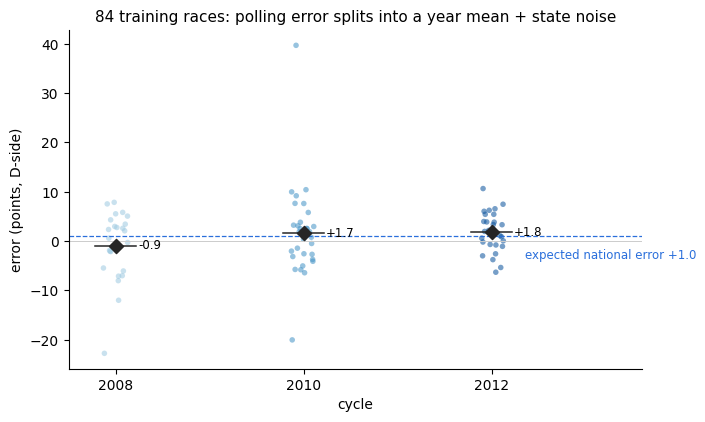

In [6]:
inc_sign = np.where(train.left_inc & ~train.right_inc, 1.0,
                    np.where(train.right_inc & ~train.left_inc, -1.0, 0.0))
train["inc"] = inc_sign
e0 = train.margin - train.poll_margin
e0d = e0 - e0.groupby(train.year).transform("mean")   # year-demeaned
BETA_INC = float(np.clip((e0d * inc_sign).sum() / (inc_sign ** 2).sum(), -2.5, 2.5))
train["pred_margin"] = train.poll_margin + BETA_INC * train.inc
train["err"] = train.margin - train.pred_margin
print(f"incumbency bump (D-side framing): {BETA_INC:+.2f} points")

yr = train.groupby("year").agg(n=("err", "size"), mean_err=("err", "mean"),
                               sd_err=("err", "std"))
yr["se_err"] = yr.sd_err / np.sqrt(yr.n)
print("\nerror = actual - (poll + bump), by year:")
print(yr.to_string())

mu_y = train.groupby("year")["err"].mean()
n_y = train.groupby("year")["err"].size()
s2_y = train.groupby("year")["err"].var(ddof=1)
w = n_y / n_y.sum()
NAT_MEAN = float((w * mu_y).sum())
s2_state = float(((n_y - 1) * s2_y).sum() / (n_y - 1).sum())
s2_mu = float(((mu_y - mu_y.mean()) ** 2).sum() / (len(n_y) - 1))
s2_nat_raw = s2_mu - s2_state * float((1 / n_y).mean())
SIGMA_NAT_FLOOR = 2.0
SIGMA_NAT = max(np.sqrt(max(s2_nat_raw, 0.0)), SIGMA_NAT_FLOOR)
SIGMA_STATE = np.sqrt(s2_state)
print(f"\nnational: mean {NAT_MEAN:+.2f}, sigma raw {np.sqrt(max(s2_nat_raw, 0.0)):.2f}"
      f" -> floored {SIGMA_NAT:.2f}")
print(f"state:    sigma {SIGMA_STATE:.2f}")
print(f"implied pairwise error correlation between states: "
      f"{SIGMA_NAT**2 / (SIGMA_NAT**2 + SIGMA_STATE**2):.2f}")

# the picture: errors by year, year means marked
fig, ax = plt.subplots(figsize=(7.4, 4.4))
rng_jit = np.random.default_rng(7)
for y in TRAIN_YEARS:
    errs = train.loc[train.year == y, "err"]
    ax.scatter(y + rng_jit.uniform(-0.13, 0.13, len(errs)), errs, s=16,
               alpha=0.55, color=YEAR_COLOR[y], edgecolor="none")
    ax.scatter([y], [errs.mean()], marker="D", s=52, color="0.15", zorder=5)
    ax.plot([y - 0.22, y + 0.22], [errs.mean()] * 2, color="0.15", lw=1.1, zorder=4)
ax.axhline(0, color="0.8", lw=0.7)
ax.axhline(NAT_MEAN, color="#2a6fdb", lw=0.9, ls="--")
ax.annotate(f"expected national error {NAT_MEAN:+.1f}", (2012.35, NAT_MEAN - 2.6),
            fontsize=8.5, color="#2a6fdb", va="top")
ax.set_xlim(2007.5, 2013.6)
for y in TRAIN_YEARS:
    ax.annotate(f"{train.loc[train.year == y, 'err'].mean():+.1f}",
                (y + 0.24, train.loc[train.year == y, "err"].mean()),
                fontsize=8.5, va="center")
ax.set(xticks=TRAIN_YEARS, xlabel="cycle", ylabel="error (points, D-side)",
       title="84 training races: polling error splits into a year mean + state noise")


## 5 · Projecting 2014

Freeze everything fitted above — bump, variances, national mean, lean slope — and simulate the 2014 map 20,000 times. Each night: draw one national error N(+0.9, 2.0²) shared by all 35 races, an independent N(0, 7.2²) per race, add both to each predicted margin, and score the left candidate by whether the sum clears zero.

Win rate = fraction of nights won. The naive model is identical minus the national draw. South Dakota's margin comes from the lean fit; Kansas's left side (Orman) counts toward neither party.

In [7]:
test = races[races.year == TEST_YEAR].copy()
test["inc"] = np.where(test.left_inc & ~test.right_inc, 1.0,
                       np.where(test.right_inc & ~test.left_inc, -1.0, 0.0))
test["use_lean"] = test.poll_margin.isna()
test["pred_margin"] = np.where(test.use_lean, test.lean_pred,
                               test.poll_margin + BETA_INC * test.inc)
test["actual_win"] = test.margin > 0

rng = np.random.default_rng(SEED)
nat = rng.normal(NAT_MEAN, SIGMA_NAT, SIMS)
noise_c = rng.normal(0, SIGMA_STATE, (SIMS, len(test)))
margins_c = test.pred_margin.values[None, :] + nat[:, None] + noise_c
noise_n = rng.normal(0, SIGMA_STATE, (SIMS, len(test)))
margins_n = test.pred_margin.values[None, :] + noise_n
test["win_corr"] = (margins_c > 0).mean(axis=0)
test["win_naive"] = (margins_n > 0).mean(axis=0)
test["race_label"] = (test.state.str.replace(" (special)", "*", regex=False)
                      + ": " + test.left_name.str.split().str[-1]
                      + " (" + test.left_party.str.upper()
                      + ") v " + test.right_name.str.split().str[-1] + " (R)")

show = (test.sort_values("win_corr", ascending=False)
        [["race_label", "pred_margin", "win_corr", "win_naive", "margin"]].copy())
show["win_corr"] = show["win_corr"].map("{:.2f}".format)
show["win_naive"] = show["win_naive"].map("{:.2f}".format)
show["use_lean_s"] = test.sort_values("win_corr", ascending=False)["use_lean"].map(
    {True: " <- lean backstop", False: ""}).values
print(f"2014 win rates, correlated error model ({SIMS:,} sims, "
      f"nat ~ N({NAT_MEAN:+.1f}, {SIGMA_NAT:.0f}²), state ~ N(0, {SIGMA_STATE:.1f}²)):")
print(show.to_string(index=False))

2014 win rates, correlated error model (20,000 sims, nat ~ N(+1.0, 2²), state ~ N(0, 7.2²)):
                                race_label  pred_margin win_corr win_naive  margin        use_lean_s
         Hawaii*: Schatz (D) v Cavasso (R)         50.6     1.00      1.00    43.2                  
     Rhode Island: Reed (D) v Zaccaria (R)         54.5     1.00      1.00    41.4                  
           Oregon: Merkley (D) v Wehby (R)         24.9     1.00      1.00    20.4                  
      Massachusetts: Markey (D) v Herr (R)         21.9     1.00      1.00    23.9                  
            Delaware: Coons (D) v Wade (R)         21.6     1.00      1.00    13.9                  
         New Jersey: Booker (D) v Bell (R)         18.4     1.00      0.99    13.8                  
       Illinois: Durbin (D) v Oberweis (R)         15.1     0.98      0.98    11.3                  
           Michigan: Peters (D) v Land (R)         14.2     0.98      0.98    13.8                 

races where the two models disagree most:
  Georgia      corr 0.42 vs naive 0.35  (polls -2.7, actual -7.8)
  Kansas       corr 0.48 vs naive 0.42  (polls -1.4, actual -11.1)
  Iowa         corr 0.46 vs naive 0.40  (polls -1.7, actual -8.7)
  Colorado     corr 0.51 vs naive 0.46  (polls -0.8, actual -2.1)


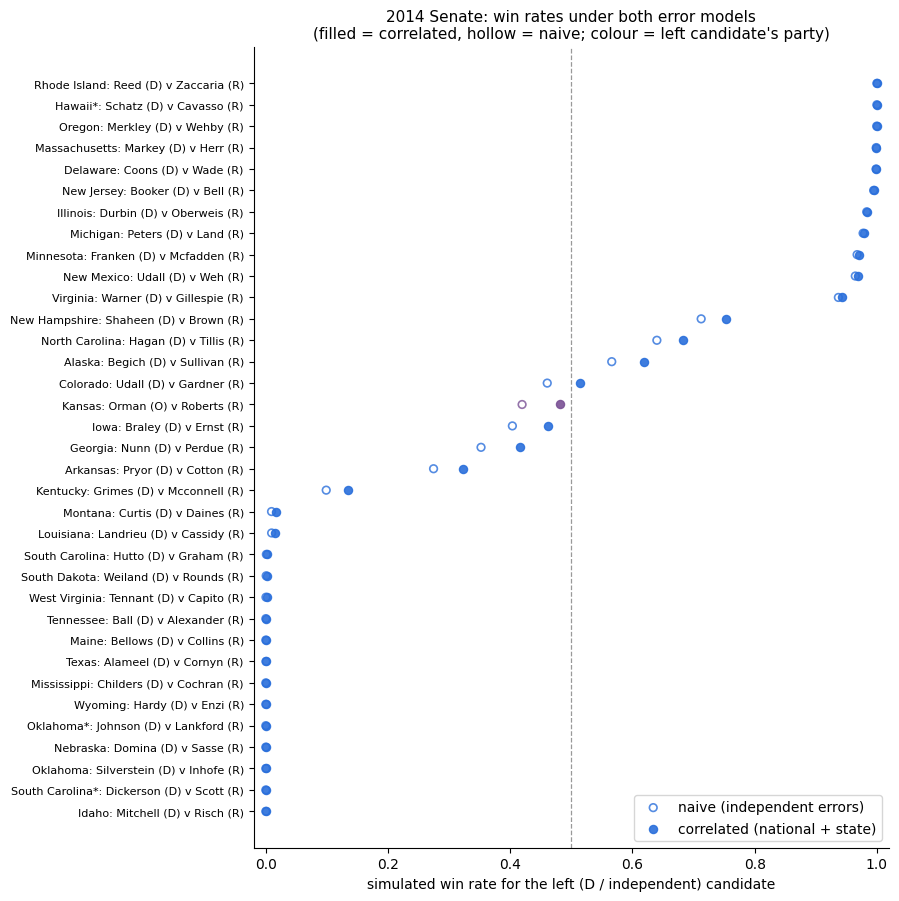

In [8]:
order = test.sort_values("win_corr", ascending=True).reset_index()
fig, ax = plt.subplots(figsize=(8.2, 10.4))
for party, color in PARTY_COLOR.items():
    sub = order[order.left_party == party]
    ax.scatter(sub.win_naive, sub.index, s=30, facecolor="none",
               edgecolor=color, linewidth=1.2, alpha=0.8,
               label="naive (independent errors)" if party == "d" else None)
    ax.scatter(sub.win_corr, sub.index, s=34, color=color, alpha=0.9,
               label="correlated (national + state)" if party == "d" else None)
ax.axvline(0.5, color="0.6", lw=0.9, ls="--")
ax.set_yticks(order.index)
ax.set_yticklabels(order.race_label, fontsize=8)
ax.set(xlabel="simulated win rate for the left (D / independent) candidate",
       xlim=(-0.02, 1.02),
       title="2014 Senate: win rates under both error models\n"
             "(filled = correlated, hollow = naive; colour = left candidate's party)")
handles, labels = ax.get_legend_handles_labels()
uniq = dict(zip(labels, handles))
ax.legend(uniq.values(), uniq.keys(), loc="lower right")
print("races where the two models disagree most:")
gap = test.assign(g=(test.win_corr - test.win_naive).abs()).nlargest(4, "g")
for _, r in gap.iterrows():
    print(f"  {r.state:12s} corr {r.win_corr:.2f} vs naive {r.win_naive:.2f}"
          f"  (polls {r.pred_margin:+.1f}, actual {r.margin:+.1f})")

actual D seats: 12 (Kansas's Orman excluded — independent)
P(D seats >= 16): correlated 0.33   naive 0.20
P(D seats >= 18): correlated 0.04   naive 0.01
P(D seats <= 12): correlated 0.08   naive 0.09

sigma_nat sensitivity (national error sd 0 / 2 / 4):
  sigma_nat=0: seat sd 1.38, P(D>=18) 0.007, P(D<=12) 0.086
  sigma_nat=2: seat sd 1.63, P(D>=18) 0.043, P(D<=12) 0.077
  sigma_nat=4: seat sd 2.19, P(D>=18) 0.100, P(D<=12) 0.158


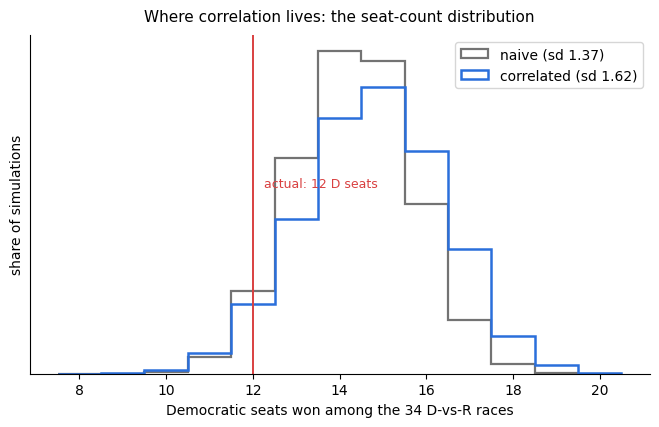

In [9]:
d_mask = (test.left_party == "d").values
seats_c = (margins_c[:, d_mask] > 0).sum(axis=1)
seats_n = (margins_n[:, d_mask] > 0).sum(axis=1)
actual_d_seats = int(((test.left_party == "d") & test.actual_win).sum())

bins = np.arange(7.5, 21.5, 1.0)
fig, ax = plt.subplots(figsize=(8.0, 4.4))
ax.hist(seats_n, bins=bins, histtype="step", lw=1.6, color="0.45",
        density=True, label=f"naive (sd {seats_n.std():.2f})")
ax.hist(seats_c, bins=bins, histtype="step", lw=1.8, color="#2a6fdb",
        density=True, label=f"correlated (sd {seats_c.std():.2f})")
ax.axvline(actual_d_seats, color="#d94040", lw=1.4)
ax.annotate(f"actual: {actual_d_seats} D seats", (actual_d_seats + 0.25, 0.55),
            xycoords=("data", "axes fraction"), fontsize=9, color="#d94040")
ax.set(xlabel="Democratic seats won among the 34 D-vs-R races",
       ylabel="share of simulations", yticks=[])
ax.legend(loc="upper right")
ax.set_title("Where correlation lives: the seat-count distribution", pad=10)

print(f"actual D seats: {actual_d_seats} (Kansas's Orman excluded — independent)")
for k in (16, 18):
    print(f"P(D seats >= {k}): correlated {(seats_c >= k).mean():.2f}"
          f"   naive {(seats_n >= k).mean():.2f}")
print(f"P(D seats <= {actual_d_seats}): correlated {(seats_c <= actual_d_seats).mean():.2f}"
      f"   naive {(seats_n <= actual_d_seats).mean():.2f}")
print("\nsigma_nat sensitivity (national error sd 0 / 2 / 4):")
for sn in (0.0, 2.0, 4.0):
    nc = rng.normal(NAT_MEAN, sn, SIMS) if sn else np.zeros(SIMS)
    ms = test.pred_margin.values[None, :] + nc[:, None] + noise_c
    ss = (ms[:, d_mask] > 0).sum(axis=1)
    print(f"  sigma_nat={sn:.0f}: seat sd {ss.std():.2f}, "
          f"P(D>=18) {(ss >= 18).mean():.3f}, P(D<=12) {(ss <= actual_d_seats).mean():.3f}")